<a href="https://colab.research.google.com/github/Pathikrit003/ML/blob/main/assignment1_mall_cust.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd

df = pd.read_csv('Mall_Customers.csv')
display(df.head())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].values
print("Shape of X :", X.shape)
print("1st 3 rows: ")
print(X[:3])

Shape of X : (200, 2)
1st 3 rows: 
[[15 39]
 [15 81]
 [16  6]]


In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = [2, 3, 4, 5, 6]

wcss_scores = []
silhouette_scores = []
results_data = []

for k in k_values:

  kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)


  cluster_labels = kmeans.fit_predict(X)


  wcss = kmeans.inertia_
  sil = silhouette_score(X, cluster_labels)
  iterations = kmeans.n_iter_
  centroids = kmeans.cluster_centers_

  wcss_scores.append(wcss)
  silhouette_scores.append(sil)

  print(f"\n************ k = {k} ************")
  print(f"WCSS                      : {wcss:.2f}")
  print(f"Silhouette Score          : {sil:.4f}")
  print(f"Iterations to Convergence : {iterations}")
  print(f"No of clusters            : {centroids.size//2}")
  print("Cluster Centroids (Income, Spending):")
  for i, center in enumerate(centroids):
    print(f"  Cluster {i}: ({center[0]:.2f}, {center[1]:.2f})")
  print(f"Assignments: {cluster_labels[:cluster_labels.size]}")

  results_data.append({
      "K": k,
      "WCSS": round(wcss, 2),
      "Silhouette Score": round(sil, 4),
      "Iterations": iterations,
  })


************ k = 2 ************
WCSS                      : 183653.33
Silhouette Score          : 0.3956
Iterations to Convergence : 8
No of clusters            : 2
Cluster Centroids (Income, Spending):
  Cluster 0: (50.91, 43.63)
  Cluster 1: (91.13, 71.00)
Assignments: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1
 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 1 1 0 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

************ k = 3 ************
WCSS                      : 106348.37
Silhouette Score          : 0.4676
Iterations to Convergence : 19
No of clusters            : 3
Cluster Centroids (Income, Spending):
  Cluster 0: (87.00, 18.63)
  Cluster 1: (86.54, 82.13)
  Cluster 2: (44.15, 49.83)
Assignments: [2 2 2 2 2 2 2 2 2

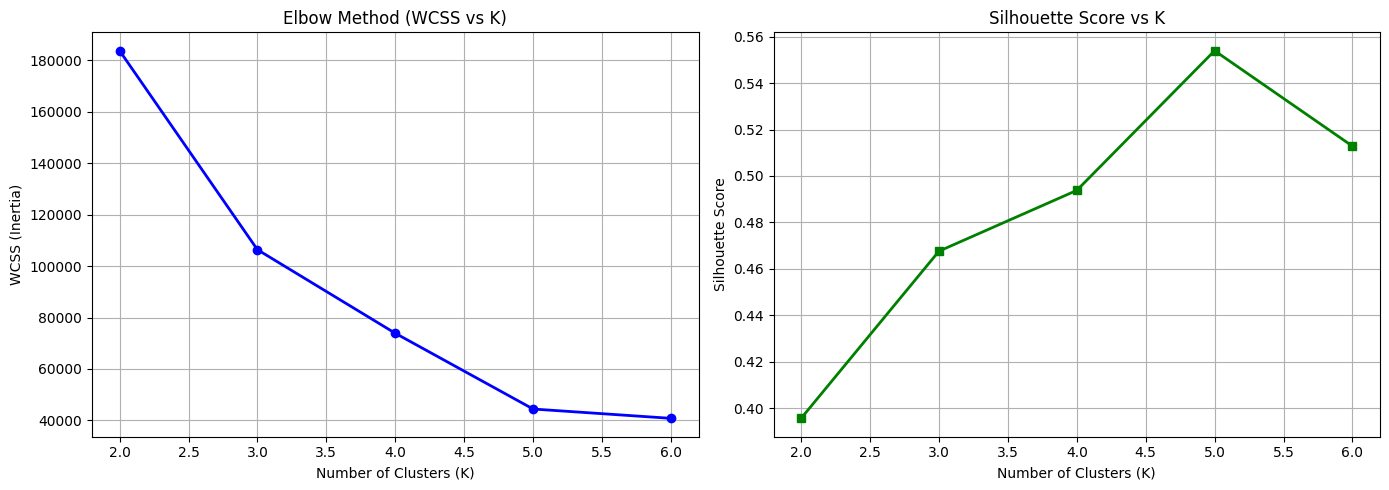

In [16]:
import matplotlib.pyplot as plt


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_values, wcss_scores, marker="o", color="blue", linewidth=2)
ax1.set_title("Elbow Method (WCSS vs K)")
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("WCSS (Inertia)")
ax1.grid(True)


ax2.plot(k_values, silhouette_scores, marker="s", color="green", linewidth=2)
ax2.set_title("Silhouette Score vs K")
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Silhouette Score")
ax2.grid(True)

plt.tight_layout()
plt.show()

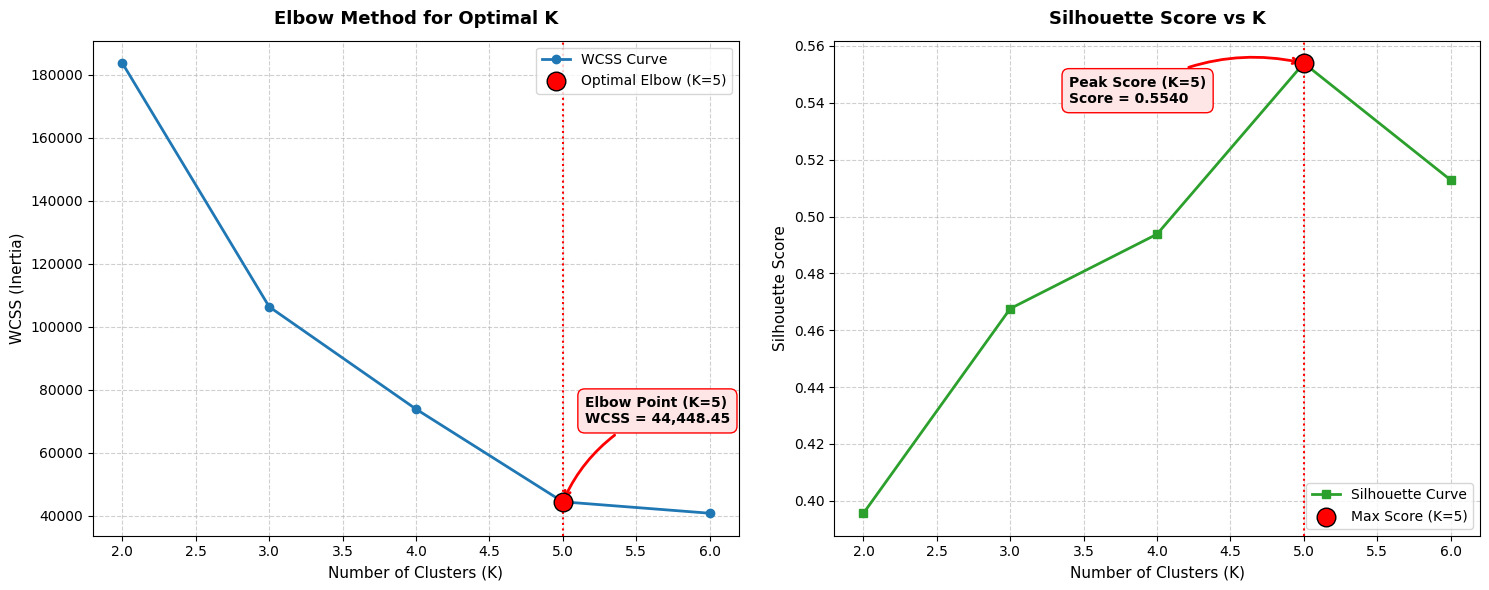

In [18]:
# -------------------------------------------------------------
# Replacement Cell 6: Evaluation Plots with K=5 Highlighted
# -------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. Elbow Method Plot (WCSS vs K)
ax1.plot(
    k_values,
    wcss_scores,
    marker="o",
    color="#1f77b4",
    linewidth=2,
    label="WCSS Curve",
)
ax1.set_title(
    "Elbow Method for Optimal K", fontsize=13, fontweight="bold", pad=12
)
ax1.set_xlabel("Number of Clusters (K)", fontsize=11)
ax1.set_ylabel("WCSS (Inertia)", fontsize=11)
ax1.grid(True, linestyle="--", alpha=0.6)

# Mark K=5 on the Elbow plot
ax1.axvline(x=5, color="red", linestyle=":", linewidth=1.5)
ax1.scatter(
    [5],
    [wcss_scores[3]],
    color="red",
    s=180,
    zorder=5,
    edgecolor="black",
    label="Optimal Elbow (K=5)",
)
ax1.annotate(
    "Elbow Point (K=5)\nWCSS = 44,448.45",
    xy=(5, wcss_scores[3]),
    xytext=(5.15, wcss_scores[3] + 25000),
    arrowprops=dict(
        arrowstyle="->", color="red", lw=2, connectionstyle="arc3,rad=0.2"
    ),
    fontsize=10,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#ffe6e6", edgecolor="red"),
)
ax1.legend(loc="upper right")

# 2. Silhouette Score Plot
ax2.plot(
    k_values,
    silhouette_scores,
    marker="s",
    color="#2ca02c",
    linewidth=2,
    label="Silhouette Curve",
)
ax2.set_title(
    "Silhouette Score vs K", fontsize=13, fontweight="bold", pad=12
)
ax2.set_xlabel("Number of Clusters (K)", fontsize=11)
ax2.set_ylabel("Silhouette Score", fontsize=11)
ax2.grid(True, linestyle="--", alpha=0.6)

# Mark K=5 on the Silhouette plot
ax2.axvline(x=5, color="red", linestyle=":", linewidth=1.5)
ax2.scatter(
    [5],
    [silhouette_scores[3]],
    color="red",
    s=180,
    zorder=5,
    edgecolor="black",
    label="Max Score (K=5)",
)
ax2.annotate(
    "Peak Score (K=5)\nScore = 0.5540",
    xy=(5, silhouette_scores[3]),
    xytext=(3.4, 0.54),
    arrowprops=dict(
        arrowstyle="->", color="red", lw=2, connectionstyle="arc3,rad=-0.2"
    ),
    fontsize=10,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#ffe6e6", edgecolor="red"),
)
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()